# Preparation

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
device

device(type='cuda')

In [51]:
content_path = "./images/content/me.jpg"
style_path = "./images/style-images/mosaic.jpg"
scaled_source_name = "scaled_source.jpg"

In [52]:
# Resize the images to have the same dimensions
source_image = Image.open(style_path)
reference_image = Image.open(content_path)

# Get dimensions of the reference image
ref_width, ref_height = reference_image.size

# Resize the source image to match the reference image's dimensions
scaled_image = source_image.resize((ref_width, ref_height), Image.LANCZOS)

# Save the scaled image (convert to RGB if needed)
if scaled_image.mode == "RGBA":
    scaled_image = scaled_image.convert("RGB")
scaled_image.save(scaled_source_name)

In [53]:
# desired size of the output image
imsize = 512 if torch.cuda.is_available() else 128  # use small size if no GPU

loader = transforms.Compose(
    [
        transforms.Resize(imsize),  # scale imported image
        transforms.ToTensor(),  # transform it into a torch tensor, scales values to [0, 1]
    ]
)


def image_loader(image_name):
    image = Image.open(image_name)
    # fake batch dimension required to fit network's input dimensions
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


style_img = image_loader(f"./{scaled_source_name}")
content_img = image_loader(content_path)

assert (
    style_img.size() == content_img.size()
), "we need to import style and content images of the same size"

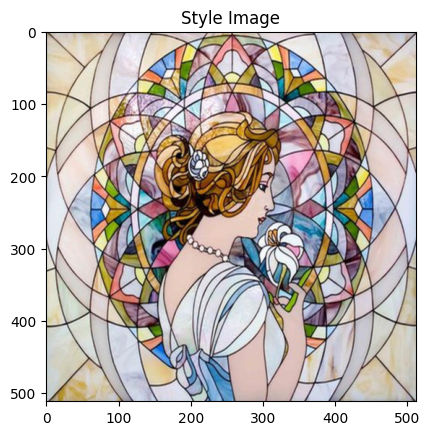

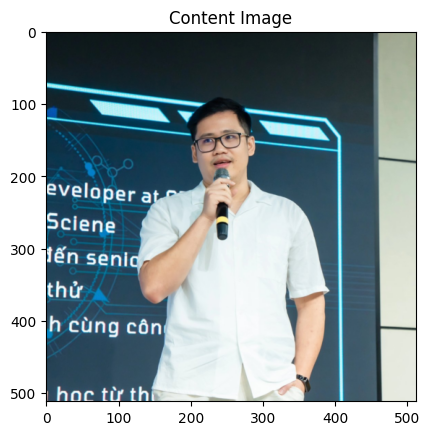

In [54]:
unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()


def imshow(tensor, title=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)  # remove the fake batch dimension
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


plt.figure()
imshow(style_img, title="Style Image")

plt.figure()
imshow(content_img, title="Content Image")

# Loss Functions

<img src="https://d2l.ai/_images/neural-style.svg" alt="NST Block Diagram" width="2000"/>


Total Loss Function
<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/d0af5b2714e61dec25599ae283047c3785f595e6" alt="total loss" width="2000"/>


## Content Loss




Content Loss Function
<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/d629f940f73e0158841476b12e8d8792a48b00a7" alt="total loss" width="2000"/>


In [55]:
class ContentLoss(nn.Module):

    def __init__(
        self,
        target,
    ):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion will throw an error.
        self.target = target.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input

## Style Loss

<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/79e17634a2fbe730fec338375992aacc3a16e602" alt="total loss" width="2000"/>


where

<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/58dd700bec587b54e6e4d8c3b8a9516581ffa021" alt="total loss" width="2000"/>


<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/c7f70b70dfc8e201e59955bc51d0b378623da0eb" alt="total loss" width="2000"/>


In [56]:
def gram_matrix(input):
    a, b, c, d = input.size()
    # a=batch size(=1)
    # b=number of feature maps
    # (c,d)=dimensions of a f. map (M=c*d)

    features = input.view(a * b, c * d)  

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)

In [57]:
class StyleLoss(nn.Module):

    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input

# Importing the model

In [58]:
# Extracts only the convolutional and pooling layers, removing the fully connected layers
# because we only need the output of the convolutional layers to compute content and style losses
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()
cnn

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [59]:
# standard normalization parameters used for preprocessing images before feeding them into the VGG19 network
# Centers the data around zero and scales it to unit variance
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])


# create a module to normalize input image so we can easily put it in a
# ``nn.Sequential``
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize ``img``
        return (img - self.mean) / self.std

In [ ]:
# VGG19 is divided into 5 blocks of convolutional layers, each followed by a max-pooling layer.

# desired depth layers to compute style/content losses:
content_layers_default = ["conv_4"]
style_layers_default = ["conv_1", "conv_2", "conv_3", "conv_4", "conv_5"]
# style_layers_default = [f"conv_{i}" for i in range(1, 17)]


def get_style_model_and_losses(
    cnn,
    normalization_mean,
    normalization_std,
    style_img,
    content_img,
    content_layers=content_layers_default,
    style_layers=style_layers_default,
):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std)

    # in order to have an iterable access to or list of content/style losses
    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f"conv_{i}"
        elif isinstance(layer, nn.ReLU):
            name = f"relu_{i}"
            # inserting custom loss modules after layers,
            # but these modules need the original activations, so we create a new tensor
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f"pool_{i}"
        elif isinstance(layer, nn.BatchNorm2d):
            name = f"bn_{i}"
        else:
            raise RuntimeError(f"Unrecognized layer: {layer.__class__.__name__}")

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[: (i + 1)]
    print(f"model: {model}")
    return model, style_losses, content_losses

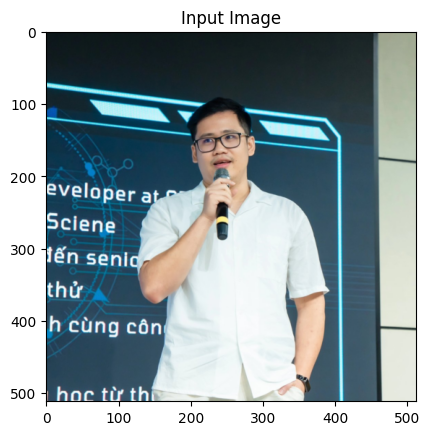

In [61]:
input_img = content_img.clone()
# input_img = torch.randn(content_img.data.size())

plt.figure()
imshow(input_img, title="Input Image")

# Gradient Descent

In [ ]:
def get_input_optimizer(input_img):
    optimizer = optim.LBFGS([input_img], lr=1)
    return optimizer

In [63]:
def run_style_transfer(
    cnn,
    normalization_mean,
    normalization_std,
    content_img,
    style_img,
    input_img,
    num_steps=300,
    style_weight=1000000,
    content_weight=1,
):
    """Run the style transfer."""
    print("Building the style transfer model..")
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, normalization_mean, normalization_std, style_img, content_img
    )

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    # We also put the model in evaluation mode, so that specific layers
    # such as dropout or batch normalization layers behave correctly.
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print("Optimizing..")
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print(
                    "Style Loss : {:4f} Content Loss: {:4f}".format(
                        style_score.item(), content_score.item()
                    )
                )
                print()

            return style_score + content_score

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

Building the style transfer model..
model: Sequential(
  (0): Normalization()
  (conv_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_1): StyleLoss()
  (relu_1): ReLU()
  (conv_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_2): StyleLoss()
  (relu_2): ReLU()
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_3): StyleLoss()
  (relu_3): ReLU()
  (conv_4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (content_loss_4): ContentLoss()
  (style_loss_4): StyleLoss()
  (relu_4): ReLU()
  (pool_4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_5): StyleLoss()
)
Optimizing..
run [50]:
Style Loss : 181.545731 Content Loss: 31.496502

run [100]:
Style Los

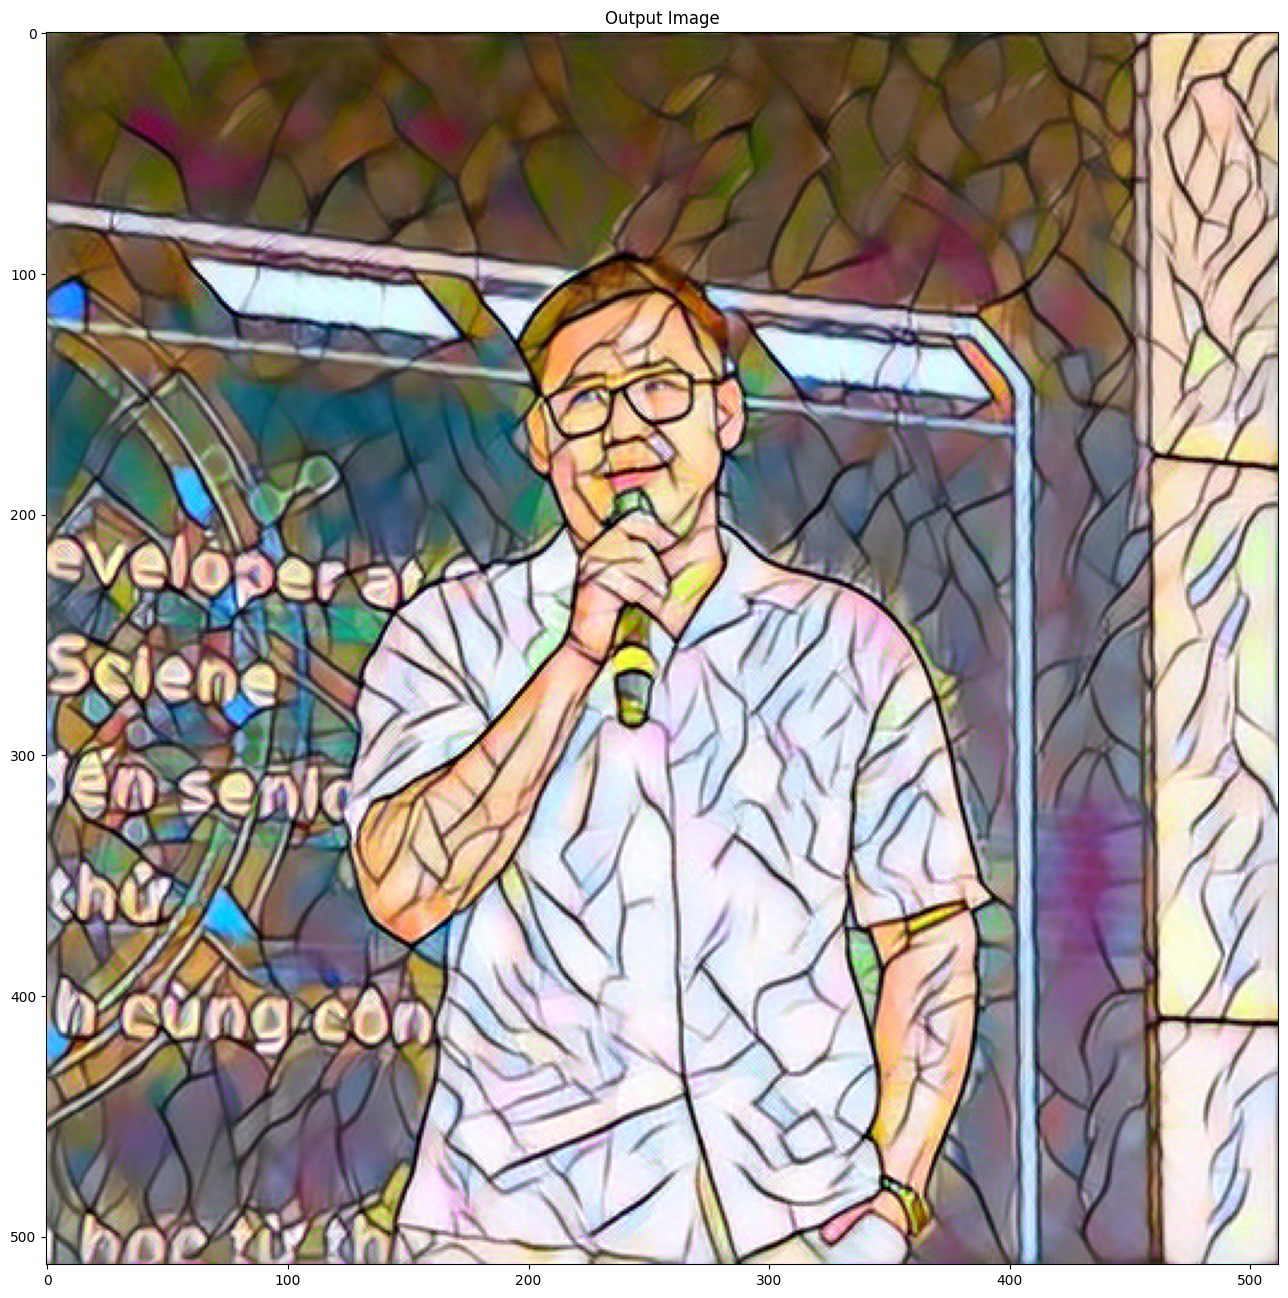

In [64]:
output = run_style_transfer(
    cnn,
    cnn_normalization_mean,
    cnn_normalization_std,
    content_img,
    style_img,
    input_img,
)

plt.figure(figsize=(16, 16))
imshow(output, title="Output Image")

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()